In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [4]:
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", plt.matplotlib.__version__)
print("Scikit-learn:", sklearn.__version__)

NumPy: 2.5.3
Pandas: 3.0.5
Matplotlib: 3.11.2
Scikit-learn: 1.9.1


# Data

In [5]:
df = pd.read_csv("../data/Telco-Customer-Churn.csv")

In [6]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df.shape

(7043, 21)

In [8]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [10]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [11]:
(df == " ").sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [12]:
df[df["TotalCharges"].isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [13]:
df["TotalCharges"].isna().sum()

np.int64(0)

In [14]:
df.loc[df["TotalCharges"].isna(), ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn


In [15]:
df["TotalCharges"].dtype

<StringDtype(storage='python', na_value=nan)>

In [16]:
df["TotalCharges"].loc[df["TotalCharges"].isna()]

Series([], Name: TotalCharges, dtype: str)

In [17]:
df.shape, df["TotalCharges"].dtype, df["TotalCharges"].isna().sum()

((7043, 21), <StringDtype(storage='python', na_value=nan)>, np.int64(0))

In [18]:
df["TotalCharges"].unique()[:20]

<StringArray>
[  '29.85',  '1889.5',  '108.15', '1840.75',  '151.65',   '820.5',  '1949.4',
   '301.9', '3046.05', '3487.95',  '587.45',   '326.8',  '5681.1',  '5036.3',
 '2686.05', '7895.15', '1022.95', '7382.25',  '528.35',  '1862.9']
Length: 20, dtype: str

In [19]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [20]:
df["TotalCharges"].dtype

dtype('float64')

In [21]:
df["TotalCharges"].isna().sum()

np.int64(11)

In [22]:
df.loc[
    df["TotalCharges"].isna(),
    ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]
]

,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


In [23]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [24]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [25]:
for column in df.columns:
    print(f"\n{column}:")
    print(df[column].unique()[:10])


customerID:
<StringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU']
Length: 10, dtype: str

gender:
<StringArray>
['Female', 'Male']
Length: 2, dtype: str

SeniorCitizen:
[0 1]

Partner:
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

Dependents:
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

tenure:
[ 1 34  2 45  8 22 10 28 62 13]

PhoneService:
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

MultipleLines:
<StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

InternetService:
<StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

OnlineSecurity:
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

OnlineBackup:
<StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str

DeviceProtection:
<StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

TechSupport:
<StringArray>
['No', 'Yes', 'No internet

In [26]:
df[["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]].describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [27]:
pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [28]:
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=[
        "0-12 months",
        "13-24 months",
        "25-48 months",
        "49-72 months"
    ]
)

In [29]:
pd.crosstab(
    df["tenure_group"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
tenure_group,,
0-12 months,52.561757,47.438243
13-24 months,71.289062,28.710938
25-48 months,79.611041,20.388959
49-72 months,90.486824,9.513176


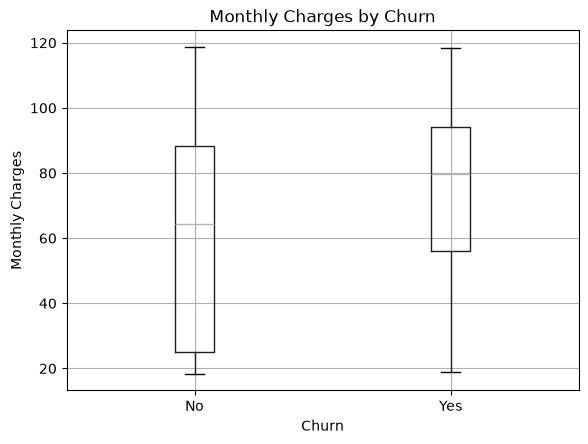

In [30]:
df.boxplot(
    column="MonthlyCharges",
    by="Churn"
)

plt.title("Monthly Charges by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

In [31]:
df.groupby("Churn")["MonthlyCharges"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


In [32]:
pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


In [33]:
pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


In [34]:
df[df["TotalCharges"].isna()][
    ["customerID", "tenure", "MonthlyCharges", "Contract", "Churn"]
]

,customerID,tenure,MonthlyCharges,Contract,Churn
488,4472-LVYGI,0,52.55,Two year,No
753,3115-CZMZD,0,20.25,Two year,No
936,5709-LVOEQ,0,80.85,Two year,No
1082,4367-NUYAO,0,25.75,Two year,No
1340,1371-DWPAZ,0,56.05,Two year,No
3331,7644-OMVMY,0,19.85,Two year,No
3826,3213-VVOLG,0,25.35,Two year,No
4380,2520-SGTTA,0,20.00,Two year,No
5218,2923-ARZLG,0,19.70,One year,No
6670,4075-WKNIU,0,73.35,Two year,No


TotalCharges contained 11 missing values, all associated with customers having zero tenure. Since these records represent only 0.16% of the dataset and imputing total charges would require an unsupported assumption, these rows were removed

In [35]:
df["TotalCharges"].isna().sum()

np.int64(11)

In [36]:
df.shape

(7043, 22)

In [37]:
df = df.dropna(subset=["TotalCharges"])

In [38]:
df["TotalCharges"].isna().sum()

np.int64(0)

In [39]:
df.shape

(7032, 22)

In [40]:
df.duplicated().sum()

np.int64(0)

In [41]:
df["customerID"].duplicated().sum()

np.int64(0)

In [42]:
pd.crosstab(
    df["Churn"],
    columns="count"
)

col_0,count
Churn,
No,5163
Yes,1869


In [43]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'tenure_group'],
      dtype='str')

| نوع          | ستون‌ها                                                                                                                                                                |
| ------------ | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| شناسه        | `customerID`                                                                                                                                                           |
| عددی         | `tenure`, `MonthlyCharges`, `TotalCharges`                                                                                                                             |
| دودویی       | `SeniorCitizen`, `gender`, `Partner`, `Dependents`, `PhoneService`, `PaperlessBilling`                                                                                 |
| چندکلاسه     | `MultipleLines`, `InternetService`, `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`, `Contract`, `PaymentMethod` |
| هدف          | `Churn`                                                                                                                                                                |
| فقط برای EDA | `tenure_group`                                                                                                                                                         |


In [44]:
X = df.drop(
    columns=["customerID", "Churn", "tenure_group"]
)
y = df["Churn"]

In [45]:
X.shape

(7032, 19)

In [46]:
y.shape

(7032,)

# Encoding

In [47]:
X.dtypes

gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
dtype: object

In [48]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [49]:
numeric_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

categorical_features = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

# Preprocessing 

In [50]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

# Train/Test Split

In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [52]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5625, 19)
X_test : (1407, 19)
y_train: (5625,)
y_test : (1407,)


In [53]:
print("Train:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTest:")
print(y_test.value_counts(normalize=True) * 100)

Train:
Churn
No     73.422222
Yes    26.577778
Name: proportion, dtype: float64

Test:
Churn
No     73.418621
Yes    26.581379
Name: proportion, dtype: float64


# Pipeline and Model

In [54]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

model_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

# Training

In [55]:
model_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['No','Yes']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remai

# Prediction

In [56]:
y_pred = model_pipeline.predict(X_test)

# Model Evaluation

In [57]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

## Accuracy

In [58]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8038379530916845


## Confusion Matrix

In [59]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[917 116]
 [160 214]]


## Classification Report

In [60]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

          No       0.85      0.89      0.87      1033
         Yes       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



In [61]:
y_proba = model_pipeline.predict_proba(X_test)

In [62]:
print(y_proba.shape)

(1407, 2)


In [63]:
y_proba_yes = y_proba[:, 1]

In [64]:
threshold = 0.5

y_pred_threshold = np.where(
    y_proba_yes >= threshold,
    "Yes",
    "No"
)

In [65]:
print((y_pred_threshold == y_pred).all())

True


In [66]:
threshold = 0.4

y_pred_04 = np.where(
    y_proba_yes >= threshold,
    "Yes",
    "No"
)

In [67]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_04))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_04
    )
)

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred_04)
)

Confusion Matrix:
[[847 186]
 [118 256]]

Classification Report:
              precision    recall  f1-score   support

          No       0.88      0.82      0.85      1033
         Yes       0.58      0.68      0.63       374

    accuracy                           0.78      1407
   macro avg       0.73      0.75      0.74      1407
weighted avg       0.80      0.78      0.79      1407

Accuracy: 0.7839374555792467


In [68]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.1, 1.0, 0.1)

results = []

for threshold in thresholds:

    y_pred_threshold = np.where(
        y_proba_yes >= threshold,
        "Yes",
        "No"
    )

    precision = precision_score(
        y_test,
        y_pred_threshold,
        pos_label="Yes"
    )

    recall = recall_score(
        y_test,
        y_pred_threshold,
        pos_label="Yes"
    )

    f1 = f1_score(
        y_test,
        y_pred_threshold,
        pos_label="Yes"
    )

    accuracy = accuracy_score(
        y_test,
        y_pred_threshold
    )

    results.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Accuracy": accuracy
    })

results_df = pd.DataFrame(results)

results_df

/mnt/d809bc61-ebac-4ca7-8e1e-e0a6d7e8f201/Documents/Programming/MyProjects/ml-customer-churn/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Threshold,Precision,Recall,F1,Accuracy
0,0.1,0.398649,0.946524,0.561014,0.606254
1,0.2,0.457746,0.868984,0.599631,0.691542
2,0.3,0.510791,0.759358,0.610753,0.742715
3,0.4,0.579186,0.684492,0.627451,0.783937
4,0.5,0.648485,0.572193,0.607955,0.803838
5,0.6,0.679245,0.385027,0.491468,0.788202
6,0.7,0.759036,0.168449,0.275711,0.764748
7,0.8,0.875000,0.018717,0.036649,0.738451
8,0.9,0.000000,0.000000,0.000000,0.734186


In [69]:
best_row = results_df.loc[
    results_df["F1"].idxmax()
]

best_row

Threshold    0.400000
Precision    0.579186
Recall       0.684492
F1           0.627451
Accuracy     0.783937
Name: 3, dtype: float64

In [70]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_proba_yes,
    pos_label="Yes"
)

auc = roc_auc_score(
    y_test,
    y_proba_yes
)

print("ROC-AUC:", auc)

ROC-AUC: 0.8359290473207676


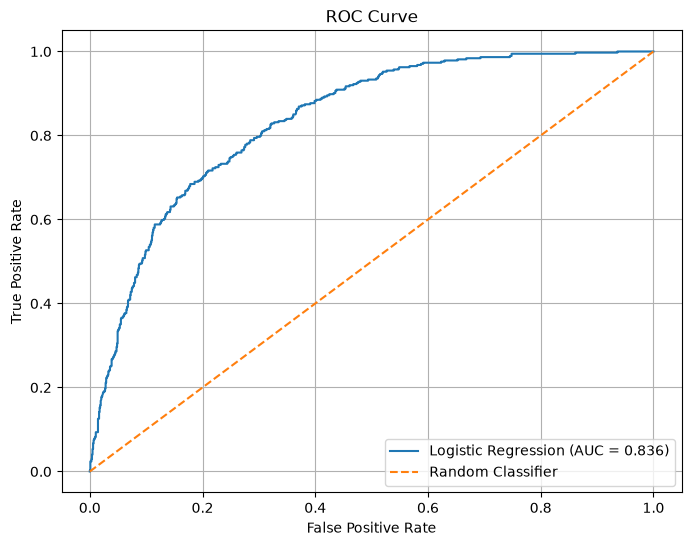

In [71]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.grid()

plt.show()

In [72]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(
    y_test,
    y_proba_yes
)

print("ROC-AUC:", auc)

ROC-AUC: 0.8359290473207676


## Decision Tree Model

In [73]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

tree_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            DecisionTreeClassifier(
                criterion="gini",
                random_state=42
            )
        )
    ]
)

In [74]:
tree_pipeline.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['No','Yes']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remai

In [75]:
y_pred_tree = tree_pipeline.predict(
    X_test
)

In [76]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

tree_accuracy = accuracy_score(
    y_test,
    y_pred_tree
)

print("Accuracy:", tree_accuracy)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred_tree
    )
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_tree
    )
)

Accuracy: 0.7306325515280739

Confusion Matrix:
[[842 191]
 [188 186]]

Classification Report:
              precision    recall  f1-score   support

          No       0.82      0.82      0.82      1033
         Yes       0.49      0.50      0.50       374

    accuracy                           0.73      1407
   macro avg       0.66      0.66      0.66      1407
weighted avg       0.73      0.73      0.73      1407



In [77]:
tree_proba = tree_pipeline.predict_proba(
    X_test
)

tree_proba_yes = tree_proba[:, 1]

In [78]:
from sklearn.metrics import roc_auc_score

tree_auc = roc_auc_score(
    y_test,
    tree_proba_yes
)

print("Decision Tree ROC-AUC:", tree_auc)

Decision Tree ROC-AUC: 0.6564546438129947


In [79]:
train_pred_tree = tree_pipeline.predict(
    X_train
)

test_pred_tree = tree_pipeline.predict(
    X_test
)

train_accuracy = accuracy_score(
    y_train,
    train_pred_tree
)

test_accuracy = accuracy_score(
    y_test,
    test_pred_tree
)

print("Train Accuracy:", train_accuracy)
print("Test Accuracy :", test_accuracy)

Train Accuracy: 0.9987555555555555
Test Accuracy : 0.7306325515280739


In [80]:
tree_pipeline_depth3 = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(
            criterion="gini",
            max_depth=3,
            random_state=42
        ))
    ]
)

tree_pipeline_depth3.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['No','Yes']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remai

In [81]:
train_pred = tree_pipeline_depth3.predict(X_train)
test_pred = tree_pipeline_depth3.predict(X_test)

print("Train Accuracy:", accuracy_score(y_train, train_pred))
print("Test Accuracy :", accuracy_score(y_test, test_pred))

Train Accuracy: 0.7907555555555555
Test Accuracy : 0.7782515991471215


In [82]:
depths = [2, 3, 4, 5, 6, 8, 10]

for depth in depths:
    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", DecisionTreeClassifier(
                criterion="gini",
                max_depth=depth,
                random_state=42
            ))
        ]
    )

    pipeline.fit(X_train, y_train)

    train_acc = accuracy_score(
        y_train,
        pipeline.predict(X_train)
    )

    test_acc = accuracy_score(
        y_test,
        pipeline.predict(X_test)
    )

    print(
        f"Depth={depth:2d} | "
        f"Train={train_acc:.3f} | "
        f"Test={test_acc:.3f}"
    )

Depth= 2 | Train=0.765 | Test=0.752
Depth= 3 | Train=0.791 | Test=0.778
Depth= 4 | Train=0.796 | Test=0.780
Depth= 5 | Train=0.799 | Test=0.790
Depth= 6 | Train=0.813 | Test=0.790
Depth= 8 | Train=0.839 | Test=0.770
Depth=10 | Train=0.875 | Test=0.758


In [83]:
from sklearn.model_selection import cross_val_score

In [84]:
tree_pipeline_depth5 = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(
            criterion="gini",
            max_depth=5,
            random_state=42
        ))
    ]
)

In [85]:
cv_scores = cross_val_score(
    tree_pipeline_depth5,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

In [86]:
print("CV scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())

CV scores: [0.77155556 0.81155556 0.79111111 0.77866667 0.78755556]
Mean CV accuracy: 0.788088888888889


In [87]:
from sklearn.model_selection import GridSearchCV

In [88]:
tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(
            criterion="gini",
            random_state=42
        ))
    ]
)

In [89]:
param_grid = {
    "model__max_depth": [2, 3, 4, 5, 6, 8, 10]
}

In [90]:
grid_search = GridSearchCV(
    estimator=tree_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy"
)

In [91]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [2, 3, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitt

In [92]:
print("Best parameters:")
print(grid_search.best_params_)

Best parameters:
{'model__max_depth': 5}


In [93]:
print("Best CV score:")
print(grid_search.best_score_)

Best CV score:
0.788088888888889


In [94]:
best_tree = grid_search.best_estimator_

In [95]:
y_pred_best = best_tree.predict(X_test)

test_accuracy = accuracy_score(
    y_test,
    y_pred_best
)

print("Final Test Accuracy:", test_accuracy)

Final Test Accuracy: 0.7896233120113717


In [96]:
param_grid = {
    "model__max_depth": [3, 4, 5, 6, 8],
    "model__min_samples_split": [2, 10, 20],
    "model__min_samples_leaf": [1, 5, 10]
}

In [97]:
grid_search = GridSearchCV(
    estimator=tree_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

In [98]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [3, 4, ...], 'model__min_samples_leaf': [1, 5, ...], 'model__min_samples_split': [2, 10, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose 

In [99]:
print("Best parameters:")
print(grid_search.best_params_)

Best parameters:
{'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}


In [100]:
print("Best CV accuracy:")
print(grid_search.best_score_)

Best CV accuracy:
0.788088888888889


In [101]:
best_tree = grid_search.best_estimator_

y_pred_best = best_tree.predict(X_test)

final_accuracy = accuracy_score(
    y_test,
    y_pred_best
)

print("Final Test Accuracy:", final_accuracy)

Final Test Accuracy: 0.7896233120113717


# Random Forest Model

In [102]:
from sklearn.ensemble import RandomForestClassifier

In [103]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ))
    ]
)

In [104]:
rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['No','Yes']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remai

In [105]:
y_pred_rf = rf_pipeline.predict(X_test)

In [106]:
rf_accuracy = accuracy_score(
    y_test,
    y_pred_rf
)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.7874911158493249


In [107]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

# Prediction
y_pred_rf = rf_pipeline.predict(X_test)

# Probability
y_proba_rf = rf_pipeline.predict_proba(X_test)

# Probability of Yes
y_proba_rf_yes = y_proba_rf[:, 1]

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# ROC-AUC
rf_auc = roc_auc_score(
    y_test,
    y_proba_rf_yes
)

print("ROC-AUC:", rf_auc)

Accuracy: 0.7874911158493249

Confusion Matrix:
[[927 106]
 [193 181]]

Classification Report:
              precision    recall  f1-score   support

          No       0.83      0.90      0.86      1033
         Yes       0.63      0.48      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.78      0.79      0.78      1407

ROC-AUC: 0.8136612120867004


| Model                   |  Accuracy |   ROC-AUC | Yes Recall |   Yes F1 |
| ----------------------- | --------: | --------: | ---------: | -------: |
| **Logistic Regression** | **0.804** | **0.836** |   **0.57** | **0.61** |
| Decision Tree           |     0.790 |     ~0.66 |      ~0.50 |    ~0.50 |
| Random Forest           |     0.787 | **0.814** |       0.48 |     0.55 |


In [108]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            random_state=42
        ))
    ]
)

In [109]:
param_grid_rf = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [5, 10, None],
    "model__min_samples_leaf": [1, 5, 10]
}

In [110]:
grid_search_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid_rf,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

In [111]:
grid_search_rf.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [5, 10, ...], 'model__min_samples_leaf': [1, 5, ...], 'model__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbos

In [112]:
print("Best parameters:")
print(grid_search_rf.best_params_)

print("\nBest CV accuracy:")
print(grid_search_rf.best_score_)

Best parameters:
{'model__max_depth': 10, 'model__min_samples_leaf': 10, 'model__n_estimators': 100}

Best CV accuracy:
0.8062222222222222


In [113]:
best_rf = grid_search_rf.best_estimator_

In [114]:
y_pred_best_rf = best_rf.predict(X_test)

print(
    "Final Test Accuracy:",
    accuracy_score(y_test, y_pred_best_rf)
)

Final Test Accuracy: 0.7924662402274343


In [115]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

# Prediction
y_pred_best_rf = best_rf.predict(X_test)

# Probability
y_proba_best_rf = best_rf.predict_proba(X_test)

# Probability of Yes
y_proba_best_rf_yes = y_proba_best_rf[:, 1]

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred_best_rf))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_best_rf))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best_rf))

# ROC-AUC
best_rf_auc = roc_auc_score(
    y_test,
    y_proba_best_rf_yes
)

print("ROC-AUC:", best_rf_auc)

Accuracy: 0.7924662402274343

Confusion Matrix:
[[930 103]
 [189 185]]

Classification Report:
              precision    recall  f1-score   support

          No       0.83      0.90      0.86      1033
         Yes       0.64      0.49      0.56       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407

ROC-AUC: 0.8368802770602214


| Model                     |  Accuracy |   ROC-AUC | Yes Precision | Yes Recall |   Yes F1 |
| ----------------------- | --------: | --------: | ------------: | ---------: | -------: |
| **Logistic Regression** | **0.804** | **0.836** |      **0.65** |   **0.57** | **0.61** |
| Decision Tree           |     0.790 |     ~0.66 |         ~0.49 |      ~0.50 |    ~0.50 |
| Random Forest           |     0.792 | **0.837** |          0.64 |       0.49 |     0.56 |


In [116]:
y_proba_rf_yes = best_rf.predict_proba(X_test)[:, 1]

In [117]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

thresholds = np.arange(0.1, 1.0, 0.1)

results_rf = []

for threshold in thresholds:

    y_pred_threshold = np.where(
        y_proba_rf_yes >= threshold,
        "Yes",
        "No"
    )

    precision = precision_score(
        y_test,
        y_pred_threshold,
        pos_label="Yes"
    )

    recall = recall_score(
        y_test,
        y_pred_threshold,
        pos_label="Yes"
    )

    f1 = f1_score(
        y_test,
        y_pred_threshold,
        pos_label="Yes"
    )

    accuracy = accuracy_score(
        y_test,
        y_pred_threshold
    )

    results_rf.append({
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Accuracy": accuracy
    })

results_rf_df = pd.DataFrame(results_rf)

results_rf_df

/mnt/d809bc61-ebac-4ca7-8e1e-e0a6d7e8f201/Documents/Programming/MyProjects/ml-customer-churn/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Threshold,Precision,Recall,F1,Accuracy
0,0.1,0.382227,0.954545,0.545872,0.577825
1,0.2,0.449153,0.850267,0.587800,0.683014
2,0.3,0.526882,0.786096,0.630901,0.755508
3,0.4,0.591241,0.649733,0.619108,0.787491
4,0.5,0.642361,0.494652,0.558912,0.792466
5,0.6,0.704545,0.331551,0.450909,0.785359
6,0.7,0.804348,0.197861,0.317597,0.773987
7,0.8,0.851852,0.061497,0.114713,0.747690
8,0.9,0.000000,0.000000,0.000000,0.734186


In [118]:
best_rf_threshold = results_rf_df.loc[
    results_rf_df["F1"].idxmax()
]

best_rf_threshold

Threshold    0.300000
Precision    0.526882
Recall       0.786096
F1           0.630901
Accuracy     0.755508
Name: 2, dtype: float64

In [119]:
cost_results = []

for threshold in thresholds:

    y_pred_threshold = np.where(
        y_proba_rf_yes >= threshold,
        "Yes",
        "No"
    )

    cm = confusion_matrix(
        y_test,
        y_pred_threshold,
        labels=["No", "Yes"]
    )

    tn, fp, fn, tp = cm.ravel()

    cost = fp * 1 + fn * 5

    cost_results.append({
        "Threshold": threshold,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "TN": tn,
        "Cost": cost
    })

cost_results_df = pd.DataFrame(cost_results)

cost_results_df

,Threshold,FP,FN,TP,TN,Cost
0,0.1,577,17,357,456,662
1,0.2,390,56,318,643,670
2,0.3,264,80,294,769,664
3,0.4,168,131,243,865,823
4,0.5,103,189,185,930,1048
5,0.6,52,250,124,981,1302
6,0.7,18,300,74,1015,1518
7,0.8,4,351,23,1029,1759
8,0.9,0,374,0,1033,1870


In [120]:
best_cost_row = cost_results_df.loc[
    cost_results_df["Cost"].idxmin()
]

best_cost_row

Threshold      0.1
FP           577.0
FN            17.0
TP           357.0
TN           456.0
Cost         662.0
Name: 0, dtype: float64

In [121]:
cost_ratios = [1, 2, 5, 10]

for ratio in cost_ratios:

    costs = []

    for threshold in thresholds:

        y_pred_threshold = np.where(
            y_proba_rf_yes >= threshold,
            "Yes",
            "No"
        )

        cm = confusion_matrix(
            y_test,
            y_pred_threshold,
            labels=["No", "Yes"]
        )

        tn, fp, fn, tp = cm.ravel()

        cost = fp + ratio * fn

        costs.append({
            "Threshold": threshold,
            "Cost": cost
        })

    costs_df = pd.DataFrame(costs)

    best = costs_df.loc[costs_df["Cost"].idxmin()]

    print(
        f"FN cost = {ratio} × FP cost"
    )
    print(best)
    print()

FN cost = 1 × FP cost
Threshold      0.5
Cost         292.0
Name: 4, dtype: float64

FN cost = 2 × FP cost
Threshold      0.3
Cost         424.0
Name: 2, dtype: float64

FN cost = 5 × FP cost
Threshold      0.1
Cost         662.0
Name: 0, dtype: float64

FN cost = 10 × FP cost
Threshold      0.1
Cost         747.0
Name: 0, dtype: float64



| Cost Ratio (FN vs FP) | Optimal Threshold | Total Cost |
| :--- | :--- | :--- |
| **1×** | 0.5 | 292 |
| **2×** | 0.3 | 424 |
| **5×** | 0.1 | 662 |
| **10×** | 0.1 | 747 |

In [122]:
final_model = model_pipeline

In [123]:
model_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

In [124]:
feature_names = model_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

feature_names

array(['num__SeniorCitizen', 'num__tenure', 'num__MonthlyCharges',
       'num__TotalCharges', 'cat__gender_Female', 'cat__gender_Male',
       'cat__Partner_No', 'cat__Partner_Yes', 'cat__Dependents_No',
       'cat__Dependents_Yes', 'cat__PhoneService_No',
       'cat__PhoneService_Yes', 'cat__MultipleLines_No',
       'cat__MultipleLines_No phone service', 'cat__MultipleLines_Yes',
       'cat__InternetService_DSL', 'cat__InternetService_Fiber optic',
       'cat__InternetService_No', 'cat__OnlineSecurity_No',
       'cat__OnlineSecurity_No internet service',
       'cat__OnlineSecurity_Yes', 'cat__OnlineBackup_No',
       'cat__OnlineBackup_No internet service', 'cat__OnlineBackup_Yes',
       'cat__DeviceProtection_No',
       'cat__DeviceProtection_No internet service',
       'cat__DeviceProtection_Yes', 'cat__TechSupport_No',
       'cat__TechSupport_No internet service', 'cat__TechSupport_Yes',
       'cat__StreamingTV_No', 'cat__StreamingTV_No internet service',
       'cat__

In [125]:
model_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['No','Yes']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['gender','SeniorCitizen','Partner',...,'PaymentMethod','MonthlyCharges', 'TotalCharges']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remai

In [126]:
coefficients = model_pipeline.named_steps[
    "model"
].coef_[0]

In [127]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

In [128]:
feature_importance["AbsoluteCoefficient"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    "AbsoluteCoefficient",
    ascending=False
)

feature_importance.head(20)

,Feature,Coefficient,AbsoluteCoefficient
1,num__tenure,-1.352313,1.352313
38,cat__Contract_Two year,-0.779030,0.779030
3,num__TotalCharges,0.644014,0.644014
15,cat__InternetService_DSL,-0.616132,0.616132
36,cat__Contract_Month-to-month,0.613846,0.613846
16,cat__InternetService_Fiber optic,0.590184,0.590184
2,num__MonthlyCharges,-0.541006,0.541006
39,cat__PaperlessBilling_No,-0.300387,0.300387
12,cat__MultipleLines_No,-0.293470,0.293470
17,cat__InternetService_No,-0.283724,0.283724


| Feature | Coefficient | General Interpretation |
| :--- | :--- | :--- |
| **tenure** | -1.352 | Decreases Churn |
| **Contract_Two year** | -0.779 | Decreases Churn |
| **TotalCharges** | +0.644 | Increases log-odds, interpret with caution |
| **Contract_Month-to-month** | +0.614 | Increases Churn |
| **InternetService_Fiber optic** | +0.590 | Increases Churn |
| **MonthlyCharges** | -0.541 | Decreases log-odds, interpret with caution |

In [129]:
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    model_pipeline,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="accuracy"
)

In [130]:
importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm_importance.importances_mean
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

importance_df.head(15)

,Feature,Importance
4,tenure,0.112154
7,InternetService,0.051457
17,MonthlyCharges,0.032125
18,TotalCharges,0.031557
14,Contract,0.026013
15,PaperlessBilling,0.010590
16,PaymentMethod,0.007249
11,TechSupport,0.006823
13,StreamingMovies,0.006681
6,MultipleLines,0.006539


| Feature | Importance |
| :--- | :--- |
| **tenure** | ███████████ |
| **InternetService** | █████ |
| **MonthlyCharges** | ███ |
| **TotalCharges** | ███ |
| **Contract** | ██ |
| **PaperlessBilling** | █ |
| **PaymentMethod** | █ |
| **TechSupport** | █ |

In [131]:
y_pred = model_pipeline.predict(X_test)

y_proba = model_pipeline.predict_proba(X_test)[:, 1]

In [132]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    pos_label="Yes"
)

recall = recall_score(
    y_test,
    y_pred,
    pos_label="Yes"
)

f1 = f1_score(
    y_test,
    y_pred,
    pos_label="Yes"
)

roc_auc = roc_auc_score(
    y_test,
    y_proba
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)

Accuracy : 0.8038379530916845
Precision: 0.6484848484848484
Recall   : 0.5721925133689839
F1 Score : 0.6079545454545454
ROC-AUC  : 0.8359290473207676


In [133]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["No", "Yes"]
)

print(cm)

[[917 116]
 [160 214]]


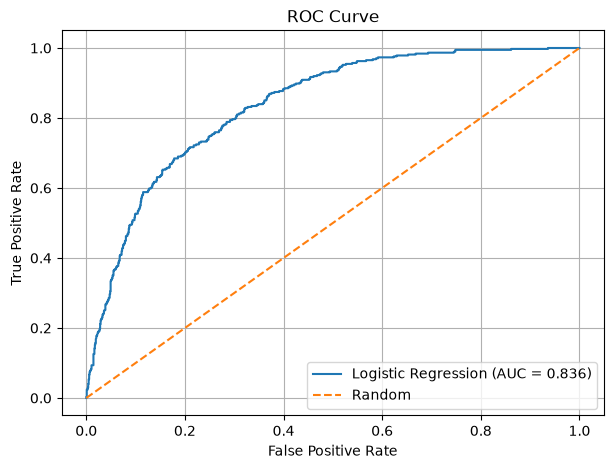

In [134]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_proba,
    pos_label="Yes"
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.grid()

plt.show()

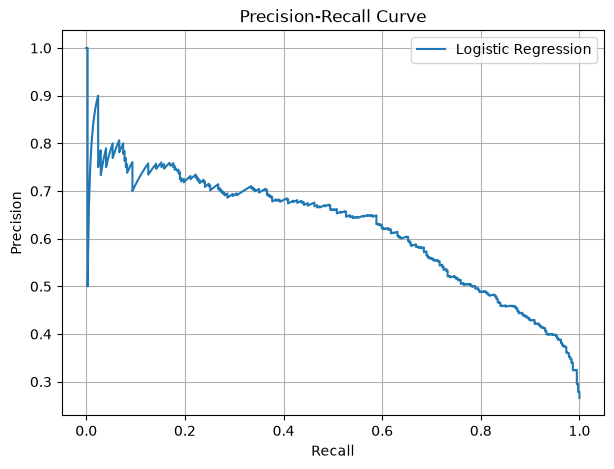

In [135]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds_pr = precision_recall_curve(
    y_test,
    y_proba,
    pos_label="Yes"
)

plt.figure(figsize=(7, 5))

plt.plot(
    recall,
    precision,
    label="Logistic Regression"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.legend()
plt.grid()

plt.show()

In [136]:
pip install joblib

Note: you may need to restart the kernel to use updated packages.


In [137]:
import joblib

joblib.dump(
    model_pipeline,
    "../models/logistic_regression_pipeline.joblib"
)

['../models/logistic_regression_pipeline.joblib']

In [138]:
import os

os.listdir("../models")

['logistic_regression_pipeline.joblib']

In [139]:
loaded_model = joblib.load(
    "../models/logistic_regression_pipeline.joblib"
)

In [140]:
y_pred_loaded = loaded_model.predict(X_test)

In [141]:
print(
    (y_pred_loaded == y_pred).all()
)

True


In [142]:
new_customer = pd.DataFrame({
    "gender": ["Female"],
    "SeniorCitizen": [0],
    "Partner": ["Yes"],
    "Dependents": ["No"],
    "tenure": [5],
    "PhoneService": ["Yes"],
    "MultipleLines": ["No"],
    "InternetService": ["Fiber optic"],
    "OnlineSecurity": ["No"],
    "OnlineBackup": ["No"],
    "DeviceProtection": ["No"],
    "TechSupport": ["No"],
    "StreamingTV": ["Yes"],
    "StreamingMovies": ["Yes"],
    "Contract": ["Month-to-month"],
    "PaperlessBilling": ["Yes"],
    "PaymentMethod": ["Electronic check"],
    "MonthlyCharges": [85.0],
    "TotalCharges": [425.0]
})

In [143]:
new_customer.shape

(1, 19)

In [144]:
new_customer.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges'],
      dtype='str')

In [145]:
print(
    list(new_customer.columns) == list(X.columns)
)

True


In [146]:
prediction = loaded_model.predict(new_customer)

print(prediction)

['Yes']


In [147]:
probability = loaded_model.predict_proba(new_customer)

print(probability)

[[0.22812047 0.77187953]]


In [148]:
print(loaded_model.named_steps["model"].classes_)

['No' 'Yes']


In [149]:
churn_probability = loaded_model.predict_proba(
    new_customer
)[:, 1]

print(churn_probability)

[0.77187953]


In [150]:
def predict_churn(model, customer):
    probability = model.predict_proba(customer)[0, 1]

    prediction = "Yes" if probability >= 0.5 else "No"

    return prediction, probability

In [152]:
prediction, probability = predict_churn(
    loaded_model,
    new_customer
)

print("Prediction:", prediction)
print("Churn probability:", probability)

Prediction: Yes
Churn probability: 0.7718795295472141
